In [51]:
import torch
print(torch.__version__)

2.13.0+cu130


In [52]:
import torch
from torch import nn
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

In [53]:
import numpy as np

In [54]:
X = np.arange(0, 1, 0.02)
y = 5.66 * X + 3.227

split = int(len(X) * 0.8)
X_train_np, X_test_np = X[:split], X[split:]
y_train_np, y_test_np = y[:split], y[split:]

X_train = torch.from_numpy(X_train_np).float().unsqueeze(1)
X_test = torch.from_numpy(X_test_np).float().unsqueeze(1)
y_train = torch.from_numpy(y_train_np).float().unsqueeze(1)
y_test = torch.from_numpy(y_test_np).float().unsqueeze(1)

In [55]:
def plot_data(X_train, y_train, X_test, y_test, predictions=None):
    plt.scatter(X_train, y_train, c='b', label='Training Data')
    plt.scatter(X_test, y_test, c='r', label='Testing Data')
    if predictions is not None:
        plt.plot(X_test, predictions, c='g', label='Predictions')
        plt.xlabel('X') 
        plt.ylabel('y')
        plt.title('X vs y')
        plt.legend()
        plt.show()

In [58]:
from torch import nn
class MyFirstNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True,dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights*x + self.bias


In [61]:
torch.manual_seed(42)
model= MyFirstNN()
model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [70]:
import matplotlib.pyplot as plt

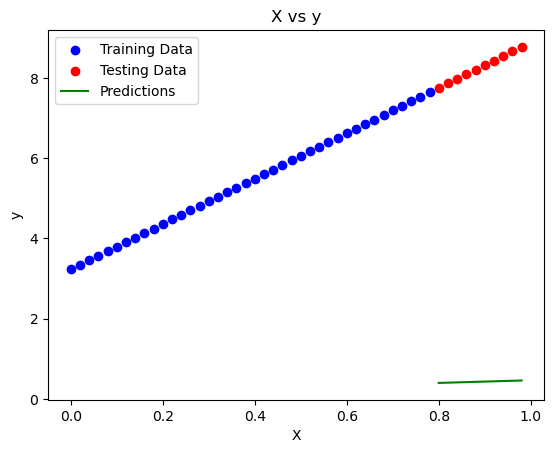

In [ ]:
# prediction before training
with torch.inference_mode():
    y_pred = model(X_test)
plot_data(X_train, y_train, X_test, y_test, predictions=y_pred)


In [72]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [78]:
epochs = 200
train_loss_list, test_loss_list = [], []
for epoch in range(epochs):
    model.train()
    train_pred = model(X_train)
    loss = loss_fn(y_train, train_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()

    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(y_test, test_pred)
    train_loss_list.append(loss.detach().numpy())
    test_loss_list.append(test_loss.detach().numpy())
    if epoch % 10 == 0:
        print(f"Epoch {epoch + 1} | Train Loss {loss.item():.6f} | Test Loss {test_loss.item():.6f}")


Epoch 1 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 11 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 21 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 31 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 41 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 51 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 61 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 71 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 81 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 91 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 101 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 111 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 121 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 131 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 141 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 151 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 161 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 171 | Train Loss 28.283581 | Test Loss 61.495411
Epoch 181 | Train Los

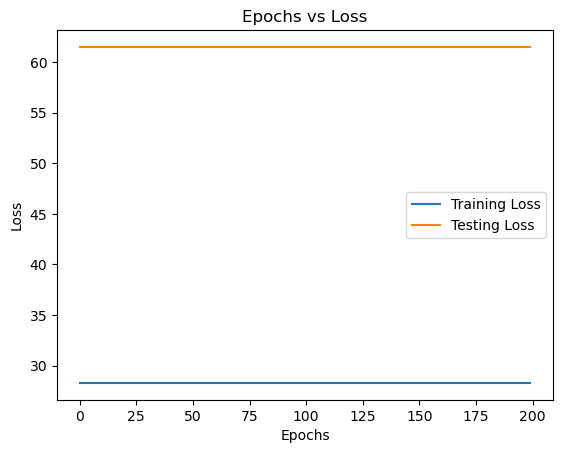

In [82]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss");
plt.xlabel("Epochs");
plt.ylabel("Loss")
plt.legend();
plt.show()